In [15]:
import pandas as pd
import numpy as np

In [16]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
import pickle
import warnings
warnings.filterwarnings("ignore")

In [17]:
df=pd.read_csv('Air_Quality.csv')

In [18]:
display(df.head())
df.info()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [19]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

In [21]:
def categorize_aqi(aqi):
    if aqi<=50:
        return "Good"
    elif aqi <=100:
        return "Moderate"
    elif aqi <=200:
        return "Poor"
    else:
        return "Severe"

df["AQI_Category"] = df["AQI"].apply(categorize_aqi)

In [22]:
if "AQI_Bucket" in df.columns:
    df["AQI_Bucket"] = df["AQI_Bucket"].fillna("Unknown")

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

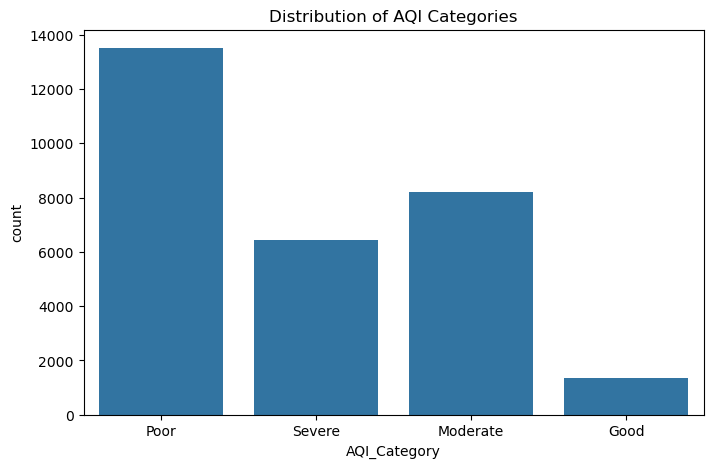

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(x="AQI_Category", data=df)
plt.title("Distribution of AQI Categories")
plt.show()

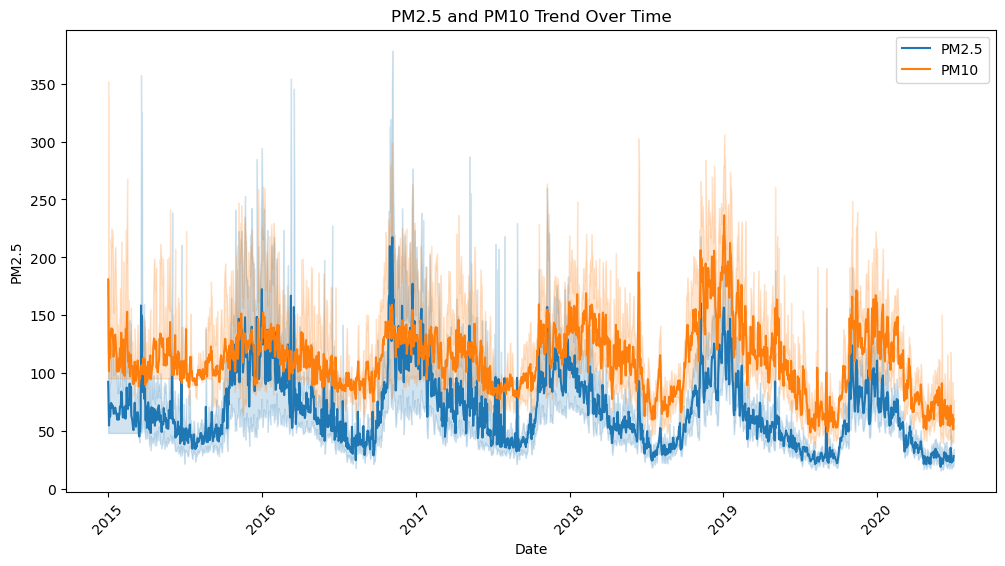

In [28]:
if "Date" in df.columns:
    df["Date"]=pd.to_datetime(df["Date"])
    plt.figure(figsize=(12,6))
    sns.lineplot(x="Date",y="PM2.5", data=df, label="PM2.5")
    sns.lineplot(x="Date",y="PM10", data=df, label="PM10")
    plt.xticks(rotation=45)
    plt.title("PM2.5 and PM10 Trend Over Time")
    plt.show()

In [29]:
features = ['PM2.5', 'PM10','NO','NO2','NOx','NH3','CO','SO2','O3']
X=df[features]
y=df['AQI']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [32]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [34]:
print("Regression Results")
print("R2 Score: ",r2_score(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))

Regression Results
R2 Score:  0.802444534574402
RMSE: 55.14762228997518


In [36]:
coeff_df=pd.DataFrame(model.coef_,features,columns=["Coefficient"])
display(coeff_df)

,Coefficient
PM2.5,59.667867
PM10,19.071392
NO,-1.640079
NO2,9.146430
NOx,4.229709
NH3,-1.376807
CO,71.010382
SO2,11.118941
O3,4.305200


In [38]:
y_class = df["AQI_Category"]

X_train,X_test,y_train,y_test = train_test_split(X,y_class,test_size=0.2,random_state=42)

In [40]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)

print("Classification Results")
print("Logistic Regression Accuracy:",accuracy_score(y_test, pred_lr))

Classification Results
Logistic Regression Accuracy: 0.7907567293042154


In [42]:
lda = LDA()
lda.fit(X_train,y_train)
pred_lda = lda.predict(X_test)
print("LDA Accuracy:", accuracy_score(y_test,pred_lda))

LDA Accuracy: 0.6937531742001015


In [43]:
qda = QDA()
qda.fit(X_train,y_train)
pred_qda = qda.predict(X_test)
print("QDA Accuracy:", accuracy_score(y_test,pred_qda))

QDA Accuracy: 0.5855764347384459


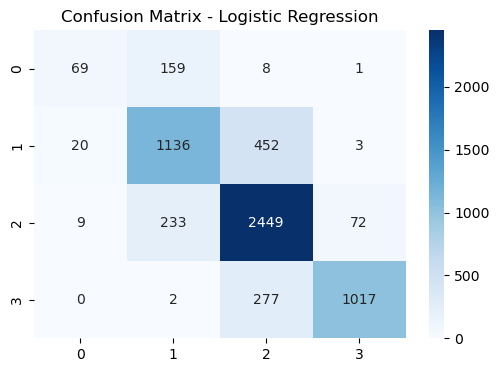

In [46]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test,pred_lr)
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [47]:
scores = cross_val_score(logreg,X,df["AQI_Category"],cv=5)
print("\nCross-validated Accuracy:",np.mean(scores))


Cross-validated Accuracy: 0.7701740965092126


In [48]:
with open("model.pkl","wb") as f:
    pickle.dump(model,f)
with open("scaler.pkl","wb") as f:
    pickle.dump(scaler,f)

print("\n model.pkl and scaler.pkl created successfully!")


 model.pkl and scaler.pkl created successfully!
